In [1]:
import os
import numpy as np
import pandas as pd
from dotenv import load_dotenv

from src.fetcher import SemanticScholarFetcher
from src.embedder import TextEmbedder
from src.scorer import AlignmentScorer
from src.topic_modeler import TopicModeler
from src.visualizer import Visualizer

load_dotenv()
print("All imports OK")

All imports OK


In [10]:
with open("data/aims_and_scope.txt", "r") as f:
    aims_and_scope = f.read()

print("Aims & Scope loaded:")
print(aims_and_scope)

Aims & Scope loaded:
The Journal of Machine Learning Research (JMLR) provides an international 
forum for the electronic and paper publication of high-quality scholarly 
articles in all areas of machine learning. All published papers are freely 
available online. JMLR seeks previously unpublished papers on machine 
learning that contain: new principled algorithms with sound empirical 
validation; experimental and/or theoretical studies yielding new insight 
into the design and behavior of learning in intelligent systems; accounts 
of applications of existing techniques that shed light on the strengths 
and weaknesses of known approaches; formalization of new learning tasks 
and presentation of new benchmarks; and developments of new analytical 
frameworks that advance theoretical studies on the complexity, geometry, 
and other mathematical properties of learning problems and algorithms.


In [34]:
key = os.getenv("S2_API_KEY")

fetcher = SemanticScholarFetcher(
    venue="Journal of Machine Learning Research",
    year_start=2015,
    year_end=2024,
    api_key=key
)

df = fetcher.fetch(max_papers=1000)
fetcher.save(df, path="data/abstracts.csv")

print(f"\nDataset shape: {df.shape}")
print(df["year"].value_counts().sort_index())

Fetching papers from 'Journal of Machine Learning Research' (2015–2024)...
Error 429: {"message": "Too Many Requests. Please wait and try again or apply for a key for higher rate limits. https://www.semanticscholar.org/product/api#api-key-form", "code": "429"}

Done. Total papers collected: 0
Saved to data/abstracts.csv

Dataset shape: (0, 0)


KeyError: 'year'

In [37]:
# Check if embeddings are still in memory
try:
    print(f"abstract_embeddings shape: {abstract_embeddings.shape}")
    print(f"scope_embedding shape: {scope_embedding.shape}")
    print("Embeddings are in memory!")
except NameError:
    print("Embeddings not in memory - need to reload")

abstract_embeddings shape: (345, 384)
scope_embedding shape: (384,)
Embeddings are in memory!


In [38]:
# Restore df from embeddings that are still in memory
# We need to reload the scorer and recompute scores

scorer = AlignmentScorer(scope_embedding=scope_embedding)
scores = scorer.compute_scores(abstract_embeddings)

# Check if df is still in memory
try:
    print(f"df shape: {df.shape}")
    print("df is in memory!")
except NameError:
    print("df not in memory")

df shape: (0, 0)
df is in memory!


In [39]:
print(f"Status of variables in memory:")
print(f"abstract_embeddings: {abstract_embeddings.shape}")
print(f"scope_embedding: {scope_embedding.shape}")
print(f"topics: {len(topics)}")
print(f"top papers in memory: {len(top)}")
print(f"bottom papers in memory: {len(bottom)}")

Status of variables in memory:
abstract_embeddings: (345, 384)
scope_embedding: (384,)
topics: 345
top papers in memory: 5
bottom papers in memory: 5


In [36]:
import requests
import time
import pandas as pd
import os

key = os.getenv("S2_API_KEY")
headers = {"x-api-key": key}

papers = []
token = None

while True:
    params = {
        "query": "machine learning",
        "venue": "Journal of Machine Learning Research",
        "fields": "title,abstract,year,venue",
        "limit": 100,
        "year": "2015-2024",
    }
    
    if token:
        params["token"] = token

    while True:
        response = requests.get(
            "https://api.semanticscholar.org/graph/v1/paper/search/bulk",
            params=params,
            headers=headers,
            timeout=30
        )
        if response.status_code == 429:
            print("Rate limit, waiting 60s...")
            time.sleep(60)
            continue
        break

    data = response.json()
    batch = data.get("data", [])
    token = data.get("token")

    for paper in batch:
        abstract = paper.get("abstract") or ""
        if len(abstract) > 50:
            papers.append({
                "paperId": paper.get("paperId", ""),
                "title": paper.get("title", ""),
                "abstract": abstract,
                "year": paper.get("year", 0),
                "venue": paper.get("venue", ""),
            })

    print(f"Collected: {len(papers)} papers")
    time.sleep(3)

    if not token:
        print("Done.")
        break

df = pd.DataFrame(papers).drop_duplicates(subset="paperId")
df.to_csv("data/abstracts.csv", index=False)
print(f"Saved: {df.shape}")
df["year"].value_counts().sort_index()

Collected: 0 papers
Done.
Saved: (0, 0)


KeyError: 'year'

In [35]:
df = pd.read_csv("data/abstracts.csv")
print(f"Loaded dataset: {df.shape}")

EmptyDataError: No columns to parse from file

In [16]:
import requests
import time
import pandas as pd

key = os.getenv("S2_API_KEY")
headers = {"x-api-key": key}

papers = []
offset = 0
limit = 100

while len(papers) < 500:
    params = {
        "query": "Journal of Machine Learning Research",
        "fields": "title,abstract,year,venue",
        "limit": limit,
        "offset": offset,
    }

    response = requests.get(
        "https://api.semanticscholar.org/graph/v1/paper/search",
        params=params,
        headers=headers,
        timeout=30
    )

    if response.status_code == 429:
        print("Rate limit hit, waiting 30 seconds...")
        time.sleep(30)
        continue

    if response.status_code != 200:
        print(f"Error: {response.status_code}")
        break

    data = response.json()
    batch = data.get("data", [])
    total = data.get("total", 0)

    if not batch:
        break

    for paper in batch:
        venue = paper.get("venue", "") or ""
        year = paper.get("year") or 0
        abstract = paper.get("abstract") or ""

        if (
            "journal of machine learning research" in venue.lower()
            and 2015 <= year <= 2024
            and len(abstract) > 50
        ):
            papers.append({
                "paperId": paper.get("paperId", ""),
                "title": paper.get("title", ""),
                "abstract": abstract,
                "year": year,
                "venue": venue,
            })

    print(f"Offset {offset}/{total} | JMLR papers: {len(papers)}")
    offset += limit
    time.sleep(2)

    if offset >= total:
        print("Done.")
        break

df = pd.DataFrame(papers).drop_duplicates(subset="paperId")
print(f"\nTotal: {df.shape}")
df.head()

Offset 0/5536 | JMLR papers: 6
Offset 100/5745 | JMLR papers: 18
Offset 200/6039 | JMLR papers: 26
Offset 300/6039 | JMLR papers: 26
Offset 400/6039 | JMLR papers: 26
Offset 500/6039 | JMLR papers: 26
Offset 600/6039 | JMLR papers: 26
Offset 700/6039 | JMLR papers: 26
Rate limit hit, waiting 30 seconds...
Offset 800/969 | JMLR papers: 26
Rate limit hit, waiting 30 seconds...
Offset 900/6039 | JMLR papers: 26
Rate limit hit, waiting 30 seconds...
Error: 400

Total: (26, 5)


,paperId,title,abstract,year,venue
0,64f6dab6b4bcf5cd792e352ea15aeca05572e21e,Tunability: Importance of Hyperparameters of M...,Modern supervised machine learning algorithms ...,2018,Journal of machine learning research
1,643da4c4de1954daeac571a82367241db012a8bf,Automatic differentiation in machine learning:...,"Derivatives, mostly in the form of gradients a...",2015,Journal of machine learning research
2,22733aac53e89446aed76dd1983bf2d74567ba88,Darts: User-Friendly Modern Machine Learning f...,"We present Darts, a Python machine learning li...",2021,Journal of machine learning research
3,d23609de72a7bdda7b17617b05b541f4ee98f948,Localisation of Regularised and Multiview Supp...,We prove a few representer theorems for a loca...,2023,Journal of machine learning research
4,323ca85c5c1ebd0ec9bf74897d8c8e8fbf203ae6,DIG: A Turnkey Library for Diving into Graph D...,Although there exist several libraries for dee...,2021,Journal of machine learning research


In [20]:
import requests
import os

key = os.getenv("S2_API_KEY")
headers = {"x-api-key": key}

response = requests.get(
    "https://api.semanticscholar.org/graph/v1/paper/search/bulk",
    params={
        "query": "machine learning",
        "venue": "Journal of Machine Learning Research",
        "fields": "title,abstract,year,venue",
        "limit": 10,
    },
    headers=headers,
    timeout=30
)

print(f"Status: {response.status_code}")
print(response.text[:500])

Status: 200
{"total": 714, "token": null, "data": [{"paperId": "00bc2153cd21001860e43758273945110f0ae40d", "title": "Consistent Feature Selection for Pattern Recognition in Polynomial Time", "venue": "Journal of machine learning research", "year": 2007, "openAccessPdf": {"url": "", "status": null, "license": null, "disclaimer": "Notice: The following paper fields have been elided by the publisher: {'abstract'}. Paper or abstract available at https://api.unpaywall.org/v2/10.5555/1314498.1314519?email=<INSERT


In [22]:
import requests
import os

key = os.getenv("S2_API_KEY")
headers = {"x-api-key": key}

response = requests.get(
    "https://api.semanticscholar.org/graph/v1/paper/search/bulk",
    params={
        "query": "machine learning",
        "venue": "Journal of Machine Learning Research",
        "fields": "title,abstract,year,venue",
        "limit": 10,
        "year": "2015-2024",
    },
    headers=headers,
    timeout=30
)

print(f"Status: {response.status_code}")
data = response.json()
print(f"Total: {data.get('total')}")

for paper in data.get("data", []):
    abstract = paper.get("abstract") or ""
    print(f"Year: {paper.get('year')} | Abstract length: {len(abstract)} | Title: {paper.get('title', '')[:50]}")

Status: 200
Total: 453
Year: 2016 | Abstract length: 0 | Title: Random Rotation Ensembles
Year: 2023 | Abstract length: 715 | Title: Accelerating optimization over the space of probab
Year: 2018 | Abstract length: 0 | Title: KELP: a Kernel-based Learning Platform
Year: 2020 | Abstract length: 1100 | Title: dalex: Responsible Machine Learning with Interacti
Year: 2020 | Abstract length: 0 | Title: AI Explainability 360: An Extensible Toolkit for U
Year: 2019 | Abstract length: 1162 | Title: Randomization as Regularization: A Degrees of Free
Year: 2016 | Abstract length: 0 | Title: Learning Using Anti-Training with Sacrificial Data
Year: 2022 | Abstract length: 1273 | Title: Identifiability and Asymptotics in Learning Homoge
Year: 2018 | Abstract length: 1526 | Title: Reverse iterative volume sampling for linear regre
Year: 2023 | Abstract length: 826 | Title: PFLlib: A Beginner-Friendly and Comprehensive Pers
Year: 2024 | Abstract length: 0 | Title: ptwt - The PyTorch Wavelet Toolbox
Ye

In [23]:
import requests
import time
import pandas as pd
import os

key = os.getenv("S2_API_KEY")
headers = {"x-api-key": key}

papers = []
token = None

while True:
    params = {
        "query": "machine learning",
        "venue": "Journal of Machine Learning Research",
        "fields": "title,abstract,year,venue",
        "limit": 100,
        "year": "2015-2024",
    }
    
    if token:
        params["token"] = token

    while True:
        response = requests.get(
            "https://api.semanticscholar.org/graph/v1/paper/search/bulk",
            params=params,
            headers=headers,
            timeout=30
        )
        if response.status_code == 429:
            print("Rate limit, waiting 30s...")
            time.sleep(30)
            continue
        break

    data = response.json()
    batch = data.get("data", [])
    token = data.get("token")

    for paper in batch:
        abstract = paper.get("abstract") or ""
        if len(abstract) > 50:
            papers.append({
                "paperId": paper.get("paperId", ""),
                "title": paper.get("title", ""),
                "abstract": abstract,
                "year": paper.get("year", 0),
                "venue": paper.get("venue", ""),
            })

    print(f"Collected: {len(papers)} papers with abstracts")
    time.sleep(2)

    if not token:
        print("Done.")
        break

df = pd.DataFrame(papers).drop_duplicates(subset="paperId")
df.to_csv("data/abstracts.csv", index=False)
print(f"\nFinal dataset: {df.shape}")
df.head()

Collected: 345 papers with abstracts
Done.

Final dataset: (345, 5)


,paperId,title,abstract,year,venue
0,01cd4111c4a122f930aa799eb5ac51ec5b41e67e,Accelerating optimization over the space of pr...,The acceleration of gradient-based optimizatio...,2023,Journal of machine learning research
1,033f5eb9b4e2c8a95702f7ac49f5c0912188c7a1,dalex: Responsible Machine Learning with Inter...,"The increasing amount of available data, compu...",2020,Journal of machine learning research
2,0386d90efab8654a58cd168bc73d86d0a3ee7ac7,Randomization as Regularization: A Degrees of ...,Random forests remain among the most popular o...,2019,Journal of machine learning research
3,046a4b8cfdc9fc69dbbdfe029c3bfc4157158d24,Identifiability and Asymptotics in Learning Ho...,Ordinary Differential Equations (ODEs) have re...,2022,Journal of machine learning research
4,053d3f6d1ae2bb23dbd4fe26150c56a04facfba2,Reverse iterative volume sampling for linear r...,We study the following basic machine learning ...,2018,Journal of machine learning research


In [24]:
print("Papers per year:")
print(df["year"].value_counts().sort_index())
print(f"\nTotal papers: {len(df)}")
print(f"Years covered: {df['year'].min()} – {df['year'].max()}")
print(f"Avg abstract length: {df['abstract'].str.len().mean():.0f} chars")

Papers per year:
year
2015    24
2016    21
2017    20
2018    29
2019    32
2020    53
2021    62
2022    39
2023    43
2024    22
Name: count, dtype: int64

Total papers: 345
Years covered: 2015 – 2024
Avg abstract length: 1226 chars


In [25]:
from src.embedder import TextEmbedder

embedder = TextEmbedder(model_name="all-MiniLM-L6-v2")

# Embed all abstracts
print("Encoding abstracts...")
abstract_embeddings = embedder.encode_from_df(df, text_col="abstract")

# Embed Aims & Scope
print("\nEncoding Aims & Scope...")
scope_embedding = embedder.encode([aims_and_scope])[0]

# Save embeddings to disk
embedder.save_embeddings(abstract_embeddings, path="data/embeddings.npy")
np.save("data/scope_embedding.npy", scope_embedding)

print(f"\nAbstracts embedding shape: {abstract_embeddings.shape}")
print(f"Scope embedding shape: {scope_embedding.shape}")

Loading model: all-MiniLM-L6-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Model loaded.
Encoding abstracts...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]


Encoding Aims & Scope...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embeddings saved to data/embeddings.npy

Abstracts embedding shape: (345, 384)
Scope embedding shape: (384,)


In [26]:
from src.scorer import AlignmentScorer

scorer = AlignmentScorer(scope_embedding=scope_embedding)

scores = scorer.compute_scores(abstract_embeddings)
df = scorer.add_scores_to_df(df, scores)

print("Alignment scores computed!")
print(f"\nMean score:   {df['alignment_score'].mean():.4f}")
print(f"Std score:    {df['alignment_score'].std():.4f}")
print(f"Min score:    {df['alignment_score'].min():.4f}")
print(f"Max score:    {df['alignment_score'].max():.4f}")

df[["title", "year", "alignment_score"]].sort_values(
    "alignment_score", ascending=False
).head(10)

Alignment scores computed!

Mean score:   0.3774
Std score:    0.0679
Min score:    0.1230
Max score:    0.6022


,title,year,alignment_score
172,The Bayesian Learning Rule,2021,0.602234
261,Distributed Learning with Regularized Least Sq...,2016,0.560884
211,Approximate Newton Methods,2017,0.525894
98,Optimal Rates of Distributed Regression with I...,2020,0.519323
323,An Entropy-Based Model for Hierarchical Learning,2022,0.508918
151,GADMM: Fast and Communication Efficient Framew...,2019,0.502089
73,Learning an Explicit Hyper-parameter Predictio...,2021,0.501252
259,FedLab: A Flexible Federated Learning Framework,2021,0.497397
277,Monte Carlo Gradient Estimation in Machine Lea...,2019,0.497130
85,Iterative Regularization for Learning with Con...,2015,0.495777


In [27]:
top, bottom = scorer.get_outliers(df, n=5)

print("TOP 5 — Most aligned papers:")
print(top[["title", "year", "alignment_score"]].to_string(index=False))

print("\nBOTTOM 5 — Least aligned papers:")
print(bottom[["title", "year", "alignment_score"]].to_string(index=False))

TOP 5 — Most aligned papers:
                                                         title  year  alignment_score
                                    The Bayesian Learning Rule  2021         0.602234
           Distributed Learning with Regularized Least Squares  2016         0.560884
                                    Approximate Newton Methods  2017         0.525894
Optimal Rates of Distributed Regression with Imperfect Kernels  2020         0.519323
              An Entropy-Based Model for Hierarchical Learning  2022         0.508918

BOTTOM 5 — Least aligned papers:
                                                                                               title  year  alignment_score
                                   Seglearn: A Python Package for Learning Sequences and Time Series  2018         0.224996
                                A Sharp Blockwise Tensor Perturbation Bound for Orthogonal Iteration  2020         0.202811
          Extracting PICO Sentences from Clinical

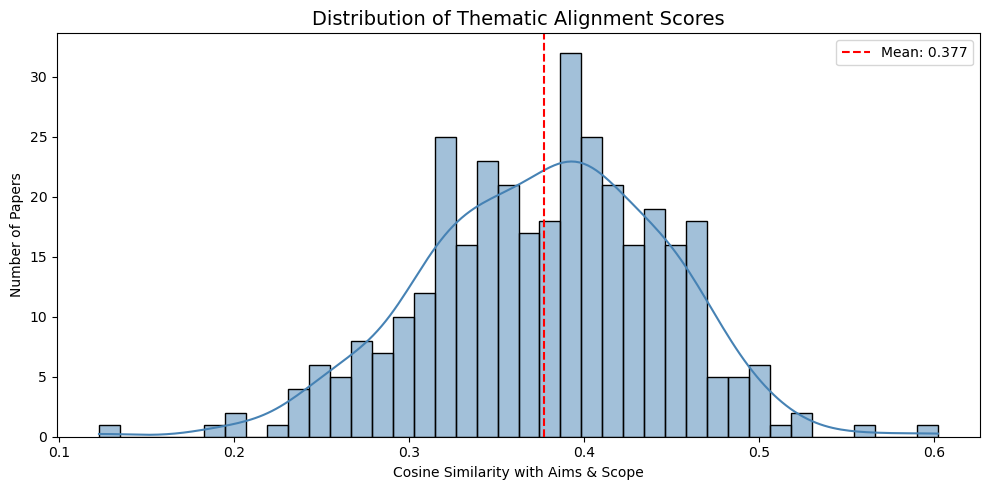

Saved: score_distribution.png


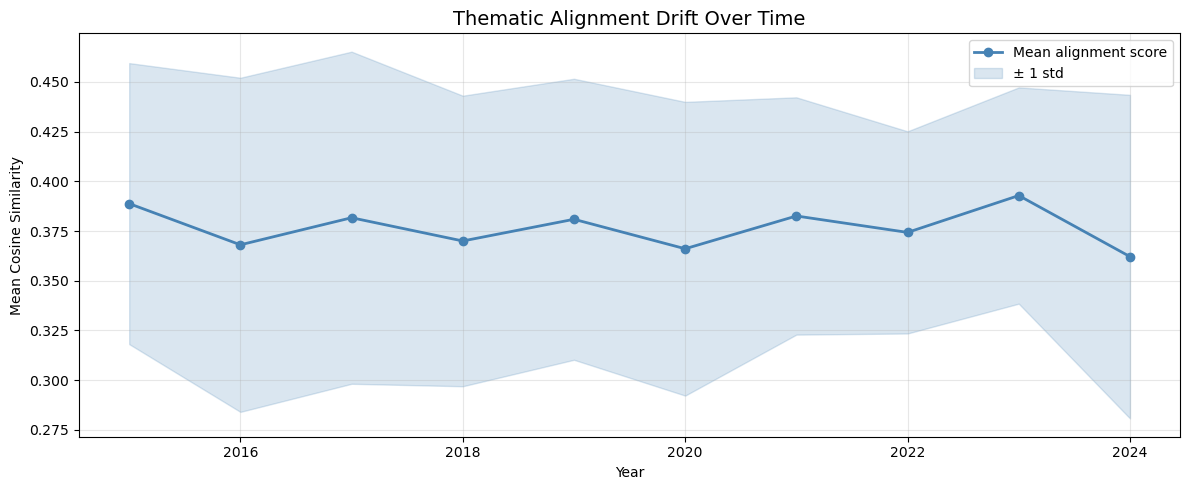

Saved: drift_over_time.png


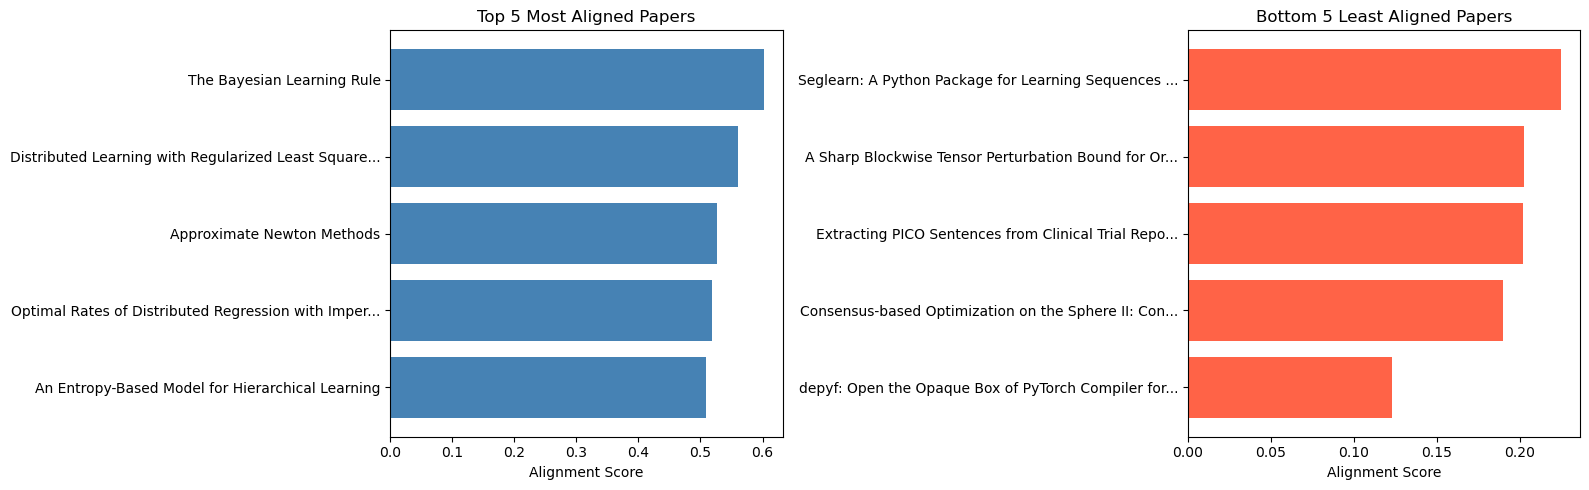

Saved: outliers.png


In [28]:
from src.visualizer import Visualizer

viz = Visualizer(output_dir="figures")

# Plot 1 — distribution of scores
viz.plot_score_distribution(df)

# Plot 2 — drift over time
viz.plot_drift_over_time(df)

# Plot 3 — outliers
viz.plot_outliers(top, bottom)

In [30]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from hdbscan import HDBSCAN

hdbscan_model = HDBSCAN(
    min_cluster_size=5,
    min_samples=3,
    prediction_data=True
)

vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2,
    ngram_range=(1, 2)
)

topic_model = BERTopic(
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    nr_topics=10,
    calculate_probabilities=True,
    verbose=True,
)

abstracts = df["abstract"].fillna("").tolist()
topics, probs = topic_model.fit_transform(abstracts, embeddings=abstract_embeddings)

df["topic"] = topics

print("Done!")
print(f"\nNumber of topics found: {topic_model.get_topic_info().shape[0]}")
topic_model.get_topic_info()

2026-06-26 21:52:02,284 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-26 21:52:02,879 - BERTopic - Dimensionality - Completed ✓
2026-06-26 21:52:02,881 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-26 21:52:02,914 - BERTopic - Cluster - Completed ✓
2026-06-26 21:52:02,915 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-26 21:52:03,087 - BERTopic - Representation - Completed ✓
2026-06-26 21:52:03,088 - BERTopic - Topic reduction - Reducing number of topics
2026-06-26 21:52:03,120 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-26 21:52:03,392 - BERTopic - Representation - Completed ✓
2026-06-26 21:52:03,408 - BERTopic - Topic reduction - Reduced number of topics from 16 to 10


Done!

Number of topics found: 10


,Topic,Count,Name,Representation,Representative_Docs
0,-1,49,-1_learning_machine_machine learning_data,"[learning, machine, machine learning, data, mo...",[Decision tree learning is a widely used appro...
1,0,121,0_learning_convergence_optimization_machine,"[learning, convergence, optimization, machine,...",[This paper considers the decentralized optimi...
2,1,65,1_learning_data_neural_models,"[learning, data, neural, models, machine, gaus...",[It is well established that neural networks w...
3,2,34,2_learning_data_causal_machine,"[learning, data, causal, machine, machine lear...","[In contemporary statistical learning, covaria..."
4,3,22,3_graph_graphs_data_distance,"[graph, graphs, data, distance, learning, appl...",[Graph coarsening is a widely used dimensional...
5,4,21,4_python_library_learning_package,"[python, library, learning, package, scikitlea...",[DoubleML is an open-source Python library imp...
6,5,12,5_problem_bandit_learning_sampling,"[problem, bandit, learning, sampling, policy, ...",[Intrinsically motivated spontaneous explorati...
7,6,8,6_learning_optimization_hyperparameter_hyperpa...,"[learning, optimization, hyperparameter, hyper...",[Meta learning has attracted much attention re...
8,7,8,7_risk_treatment_optimal_value,"[risk, treatment, optimal, value, patients, sc...",[Learning risk scores to predict dichotomous o...
9,8,5,8_reproducibility_tabular_methods_systems,"[reproducibility, tabular, methods, systems, l...",[Evaluating machine learning (ML) systems on t...


10it [00:00, 15.36it/s]


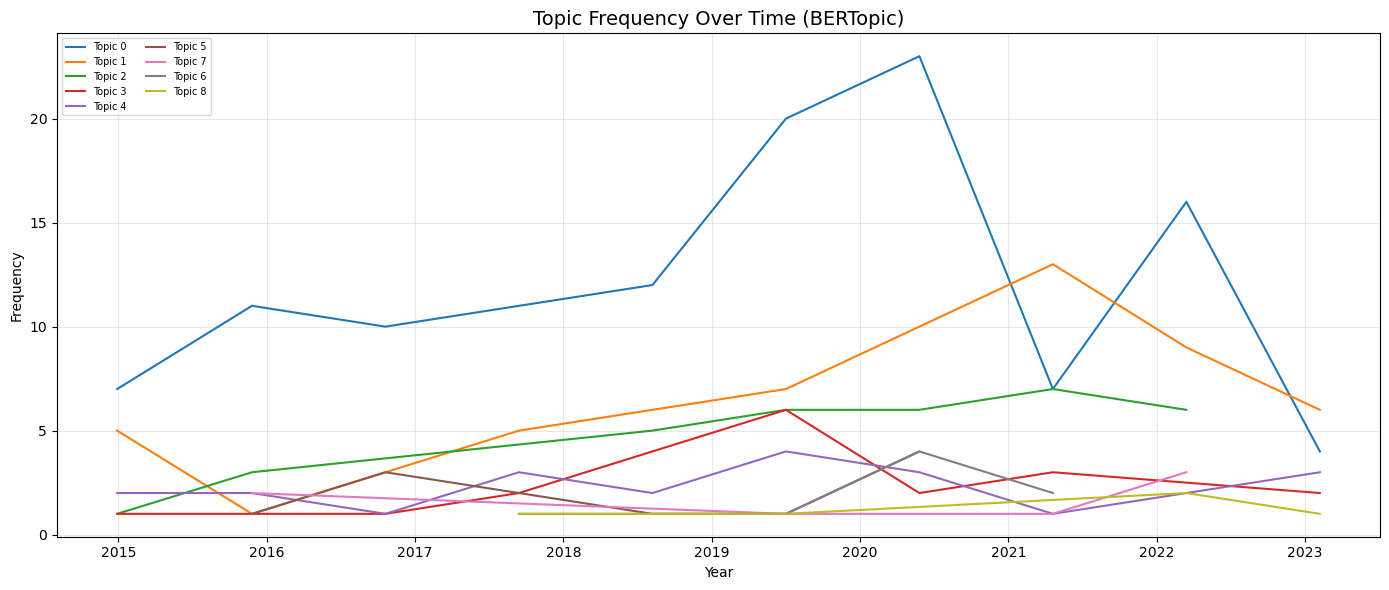

Saved: topics_over_time.png


In [31]:
topics_over_time = topic_model.topics_over_time(
    abstracts,
    df["year"].tolist(),
    nr_bins=10,
)

viz.plot_topics_over_time(topics_over_time)

2026-06-26 21:50:42,059 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-26 21:51:00,488 - BERTopic - Dimensionality - Completed ✓
2026-06-26 21:51:00,489 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-26 21:51:00,542 - BERTopic - Cluster - Completed ✓
2026-06-26 21:51:00,543 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-26 21:51:00,690 - BERTopic - Representation - Completed ✓
2026-06-26 21:51:00,690 - BERTopic - Topic reduction - Reducing number of topics
2026-06-26 21:51:00,691 - BERTopic - Topic reduction - Number of topics (15) is equal or higher than the clustered topics(2).
2026-06-26 21:51:00,692 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-26 21:51:00,851 - BERTopic - Representation - Completed ✓


Topic modeling done!

Topic info:


,Topic,Count,Name,Representation,Representative_Docs
0,0,20,0_graph_graphs_data_learning,"[graph, graphs, data, learning, node, applicat...",[Graph coarsening is a widely used dimensional...
1,1,325,1_learning_machine_data_machine learning,"[learning, machine, data, machine learning, me...",[We introduce a new second-order inertial opti...
